In [1]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from glob import glob
from pathlib import Path

from sklearn.model_selection import train_test_split

import albumentations as A

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F 

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER = os.path.join(DATASET_PATH, "av")
ROI_FOLDER = os.path.join(DATASET_PATH, "masks")

# -----------------------------

OUTPUT_DIR = "./Processed_Dataset"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_SIZE = 768

BATCH_SIZE = 2

NUM_CLASSES = 4

EPOCHS = 250

LR = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

PIN_MEMORY = True

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Folder Structure
# ============================================================

folders = [

    "train/images",
    "train/av",

    "val/images",
    "val/av",

    "test/images",
    "test/av"

]

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for folder in folders:

    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("Folder structure created.")

Folder structure created.


In [4]:
# ============================================================
# Collect Images
# ============================================================

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch in number of images, AV masks, and ROI masks."

print(f"Total Images : {len(image_paths)}")

Total Images : 50


In [5]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(

    image_paths,
    gt_paths,
    roi_paths,

    test_size=0.30,

    random_state=SEED,

    shuffle=True

)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(

    temp_images,
    temp_gt,
    temp_roi,

    test_size=0.50,

    random_state=SEED,

    shuffle=True

)

print(f"Train      : {len(train_images)}")
print(f"Validation : {len(val_images)}")
print(f"Test       : {len(test_images)}")

Train      : 35
Validation : 7
Test       : 8


In [6]:
def copy_files(images, gts, rois, split):

    image_out = os.path.join(OUTPUT_DIR, split, "images")
    gt_out = os.path.join(OUTPUT_DIR, split, "av")
    roi_out = os.path.join(OUTPUT_DIR, split, "masks")

    os.makedirs(gt_out, exist_ok=True)
    os.makedirs(roi_out, exist_ok=True)

    for img, gt, roi in zip(images, gts, rois):

        shutil.copy(img, image_out)
        shutil.copy(gt, gt_out)
        shutil.copy(roi, roi_out)
        
train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(
    image_paths,
    gt_paths,
    roi_paths,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(
    temp_images,
    temp_gt,
    temp_roi,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

copy_files(train_images, train_gt, train_roi, "train")
copy_files(val_images, val_gt, val_roi, "val")
copy_files(test_images, test_gt, test_roi, "test")

In [7]:
# ============================================================
# Create Processed Dataset Folders
# ============================================================

PROCESSED_DIR = "./Preprocessed_Dataset"

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"
]

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)

for folder in folders:
    os.makedirs(os.path.join(PROCESSED_DIR, folder), exist_ok=True)

print("Processed dataset folders created.")

Processed dataset folders created.


In [8]:
# ============================================================
# Preprocessing Helper Functions
# ============================================================

def apply_roi(image, roi):
    """
    Keep only retinal region.
    """

    roi = (roi > 0).astype(np.uint8)

    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image):
    """
    Extract green channel.
    """

    return image[:, :, 1]


def apply_clahe(green):

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(green)


def pad_to_square(image, pad_value=0):

    h, w = image.shape[:2]

    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top

    left = (size - w) // 2
    right = size - w - left

    if len(image.shape) == 2:

        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=pad_value
        )

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(pad_value, pad_value, pad_value)
    )


def resize_image(image, interpolation):

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [9]:
# ============================================================
# RGB Mask to Class Mask
# ============================================================

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [10]:
# ============================================================
# Preprocess One Sample
# ============================================================

def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    image = extract_green(image)

    image = apply_clahe(image)

    image = pad_to_square(image)

    image = resize_image(
        image,
        cv2.INTER_LINEAR
    )

    gt = rgb_to_class(gt)

    gt = pad_to_square(gt)

    gt = resize_image(
        gt,
        cv2.INTER_NEAREST
    )

    roi = pad_to_square(roi)

    roi = resize_image(
        roi,
        cv2.INTER_NEAREST
    )

    return image, gt, roi

In [11]:
# ============================================================
# Process Dataset
# ============================================================

splits = ["train", "val", "test"]

for split in splits:

    image_dir = os.path.join(OUTPUT_DIR, split, "images")
    gt_dir = os.path.join(OUTPUT_DIR, split, "av")
    roi_dir = os.path.join(OUTPUT_DIR, split, "masks")

    out_img = os.path.join(PROCESSED_DIR, split, "images")
    out_gt = os.path.join(PROCESSED_DIR, split, "av")
    out_roi = os.path.join(PROCESSED_DIR, split, "masks")

    images = sorted(glob(os.path.join(image_dir, "*")))
    gts = sorted(glob(os.path.join(gt_dir, "*")))
    rois = sorted(glob(os.path.join(roi_dir, "*")))

    for img_path, gt_path, roi_path in tqdm(
        zip(images, gts, rois),
        total=len(images),
        desc=split
    ):

        image, gt, roi = preprocess_sample(
            img_path,
            roi_path,
            gt_path
        )

        name = os.path.basename(img_path)

        cv2.imwrite(
            os.path.join(out_img, name),
            image
        )

        cv2.imwrite(
            os.path.join(out_gt, name),
            gt
        )

        cv2.imwrite(
            os.path.join(out_roi, name),
            roi
        )

print("Preprocessing completed.")

test: 100%|██████████| 8/8 [00:00<00:00,  8.13it/s]

Preprocessing completed.


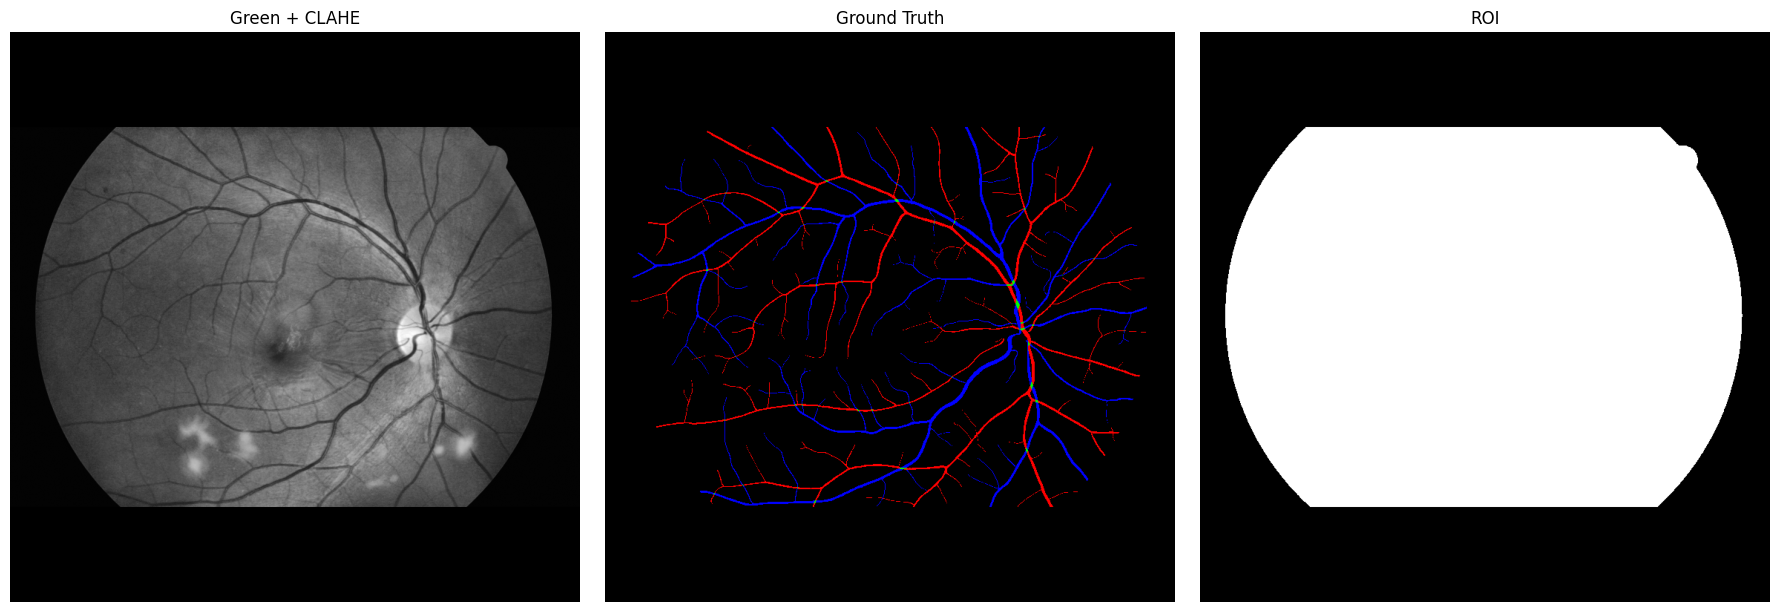

In [12]:
# ============================================================
# Visual Verification
# ============================================================

def class_to_rgb(mask):
    """
    Convert class mask back to RGB for visualization only.
    """

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


sample = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))[0]

name = os.path.basename(sample)

image = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

gt = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/av", name),
    cv2.IMREAD_GRAYSCALE
)

roi = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/masks", name),
    cv2.IMREAD_GRAYSCALE
)

gt_rgb = class_to_rgb(gt)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(image, cmap="gray")
plt.title("Green + CLAHE")
plt.axis("off")

plt.subplot(132)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(133)
plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Create Augmented Dataset
# ============================================================

AUGMENTED_DIR = "./Augmented_Dataset"

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"
]

if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)

for folder in folders:
    os.makedirs(os.path.join(AUGMENTED_DIR, folder), exist_ok=True)

print("Augmented dataset folders created.")

Augmented dataset folders created.


In [14]:
# ============================================================
# Copy Validation and Test Sets
# ============================================================

for split in ["val", "test"]:

    for folder in ["images", "av", "masks"]:

        src = os.path.join(PROCESSED_DIR, split, folder)
        dst = os.path.join(AUGMENTED_DIR, split, folder)

        for file in os.listdir(src):

            shutil.copy(
                os.path.join(src, file),
                os.path.join(dst, file)
            )

print("Validation and Test copied.")

Validation and Test copied.


In [15]:
# ============================================================
# Offline Augmentations
# ============================================================

augmentations = {

    "hflip":
    A.HorizontalFlip(p=1),

    "vflip":
    A.VerticalFlip(p=1),

    "rot_p15":
    A.Rotate(
        limit=(15,15),
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "rot_m15":
    A.Rotate(
        limit=(-15,-15),
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "brightness":
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=1
    ),

    "gamma":
    A.RandomGamma(
        gamma_limit=(80,120),
        p=1
    ),

    "elastic":
    A.ElasticTransform(
        alpha=20,
        sigma=4,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "affine":
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        cval=0,
        p=1
    )

}

In [16]:
# ============================================================
# Copy Original Training Set
# ============================================================

for folder in ["images", "av", "masks"]:

    src = os.path.join(PROCESSED_DIR, "train", folder)
    dst = os.path.join(AUGMENTED_DIR, "train", folder)

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Original training images copied.")

Original training images copied.


In [17]:
# ============================================================
# Offline Augmentation
# ============================================================

train_images = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))
train_gt = sorted(glob(os.path.join(PROCESSED_DIR, "train/av/*")))
train_roi = sorted(glob(os.path.join(PROCESSED_DIR, "train/masks/*")))

for img_path, gt_path, roi_path in tqdm(
    zip(train_images, train_gt, train_roi),
    total=len(train_images)
):

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    roi = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

    base = Path(img_path).stem

    for aug_name, aug in augmentations.items():

        if aug_name in ["brightness", "gamma"]:

            augmented = aug(image=image)

            aug_image = augmented["image"]

            aug_gt = gt.copy()

            aug_roi = roi.copy()

        else:

            augmented = aug(
                image=image,
                mask=gt,
                masks=[roi]
            )

            aug_image = augmented["image"]

            aug_gt = augmented["mask"]

            aug_roi = augmented["masks"][0]

        filename = f"{base}_{aug_name}.png"

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/images", filename),
            aug_image
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/av", filename),
            aug_gt
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/masks", filename),
            aug_roi
        )

print("Offline augmentation completed.")

100%|██████████| 35/35 [00:06<00:00,  5.21it/s]

Offline augmentation completed.


In [18]:
# ============================================================
# Dataset Statistics
# ============================================================

for split in ["train", "val", "test"]:

    n = len(glob(os.path.join(AUGMENTED_DIR, split, "images/*")))

    print(f"{split:5s} : {n}")

train : 315
val   : 7
test  : 8


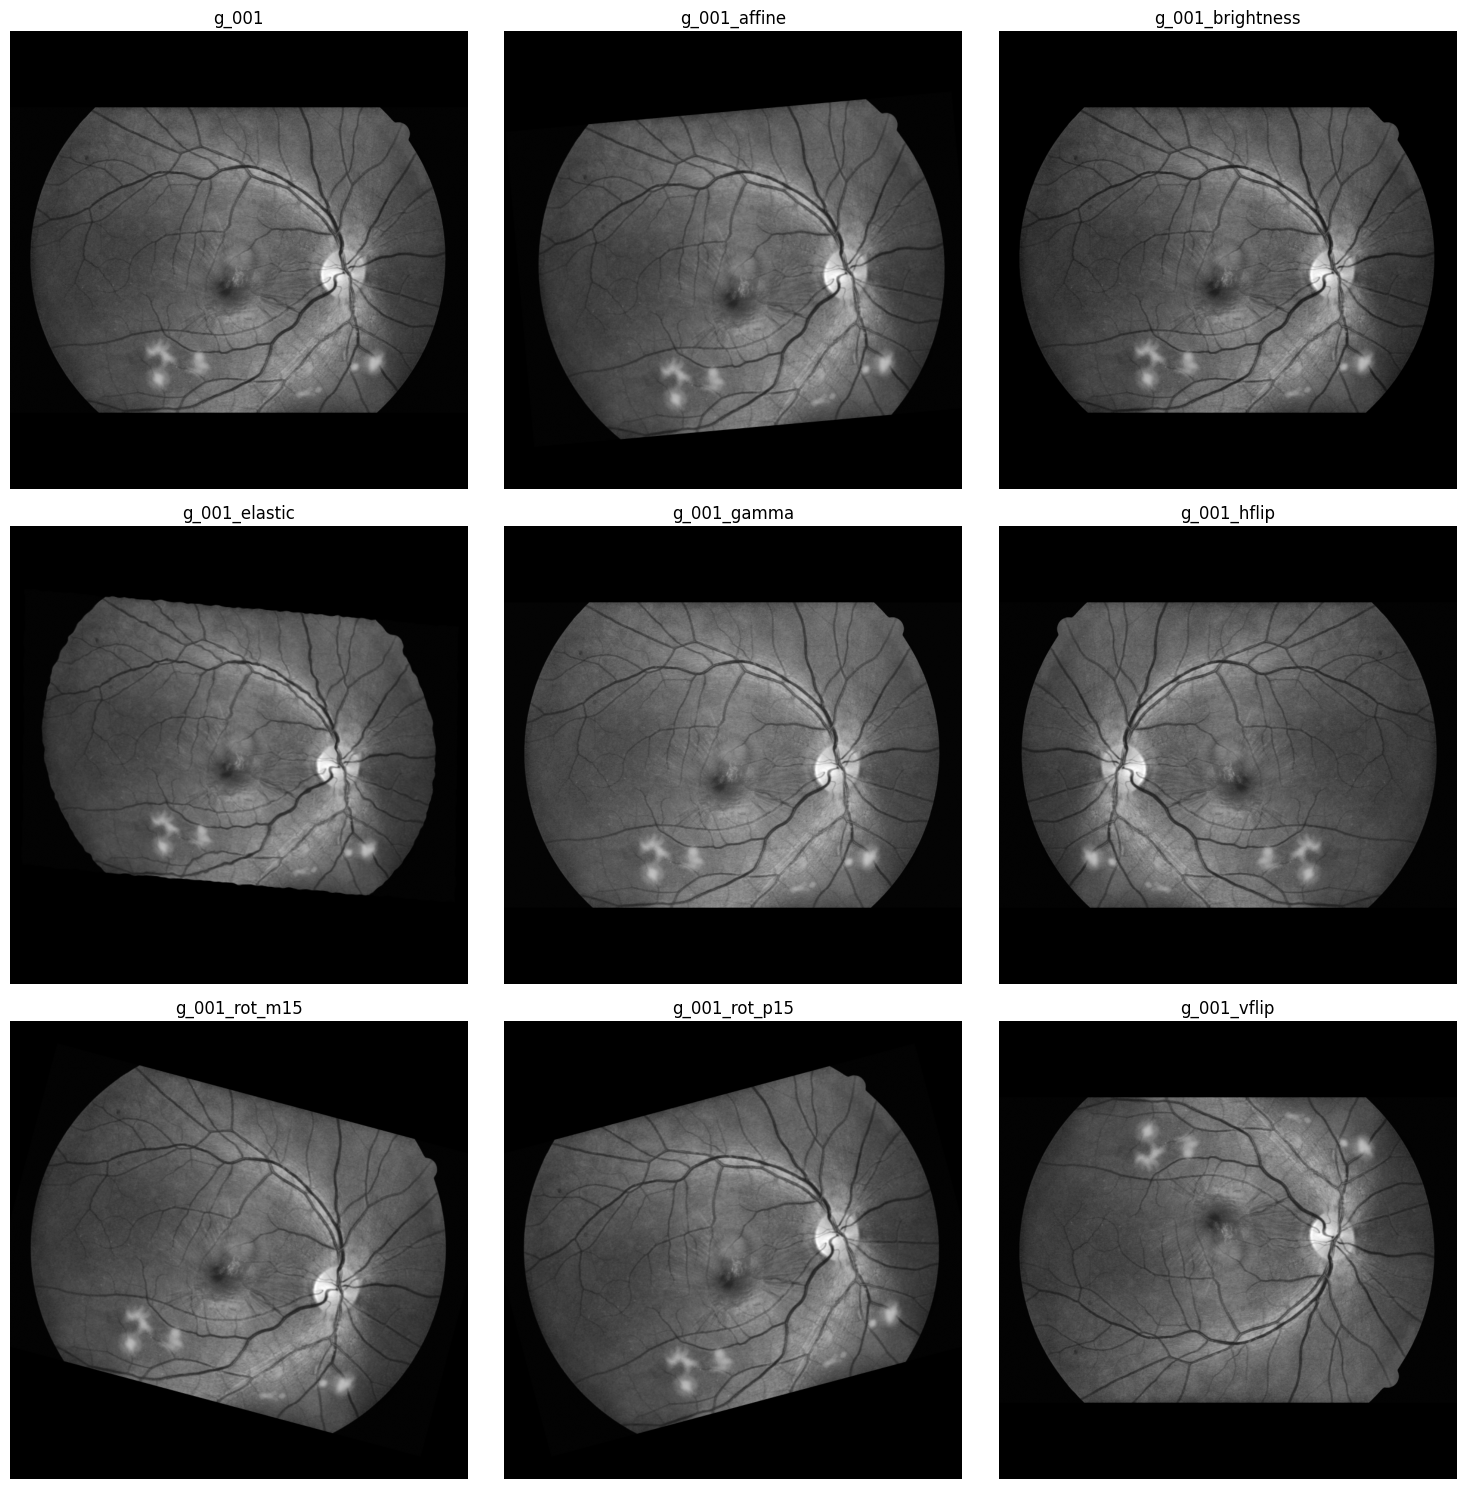

In [19]:
# ============================================================
# Visualize Augmentations
# ============================================================

samples = sorted(glob(os.path.join(AUGMENTED_DIR, "train/images/*")))[:9]

plt.figure(figsize=(15,15))

for i, sample in enumerate(samples):

    img = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(Path(sample).stem)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# Dataset Class
# ============================================================

class RetinalDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks = sorted(glob(os.path.join(mask_dir, "*")))

        assert len(self.images) == len(self.masks)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.images[idx],
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            self.masks[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = image.astype(np.float32) / 255.0

        image = np.expand_dims(image, axis=0)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask

In [21]:
# ============================================================
# DataLoaders
# ============================================================

train_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "train/images"),
    os.path.join(AUGMENTED_DIR, "train/av")

)

val_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "val/images"),
    os.path.join(AUGMENTED_DIR, "val/av")

)

test_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "test/images"),
    os.path.join(AUGMENTED_DIR, "test/av")

)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

test_loader = DataLoader(

    test_dataset,

    batch_size=1,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 315
Validation : 7
Test : 8


In [22]:
# ============================================================
# Verify Dataset
# ============================================================

images, masks = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)

print("Unique Classes :", torch.unique(masks))

Images : torch.Size([2, 1, 768, 768])
Masks  : torch.Size([2, 768, 768])
Unique Classes : tensor([0, 1, 2, 3])


In [23]:
# ============================================================
# Double Convolution Block
# ============================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [24]:
# ============================================================
# Attention Gate
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [25]:
# ============================================================
# Encoder Block
# ============================================================

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled

In [26]:
# ============================================================
# Decoder Block
# ============================================================

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

In [27]:
# ============================================================
# Attention U-Net
# ============================================================

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=1, num_classes=4):

        super().__init__()

        # ---------------- Encoder ---------------- #

        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # ---------------- Bottleneck ---------------- #

        self.bottleneck = DoubleConv(512, 1024)

        # ---------------- Decoder ---------------- #

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        # ---------------- Output ---------------- #

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        s1, p1 = self.enc1(x)

        s2, p2 = self.enc2(p1)

        s3, p3 = self.enc3(p2)

        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d4 = self.dec4(b, s4)

        d3 = self.dec3(d4, s3)

        d2 = self.dec2(d3, s2)

        d1 = self.dec1(d2, s1)

        out = self.out(d1)

        return out

In [28]:
# ============================================================
# Build Model
# ============================================================

model = AttentionUNet(
    in_channels=1,
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)


AttentionUNet(
  (enc1): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), 

In [29]:
# ============================================================
# Forward Pass Verification
# ============================================================

dummy = torch.randn(
    2,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(DEVICE)

with torch.no_grad():

    output = model(dummy)

print("Input Shape :", dummy.shape)

print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 1, 768, 768])
Output Shape: torch.Size([2, 4, 768, 768])


In [30]:
# ============================================================
# Model Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")


Total Parameters      : 31,388,208
Trainable Parameters  : 31,388,208


In [31]:
# ============================================================
# Compute Class Weights (run once, from training masks)
# ============================================================

def compute_class_weights(mask_dir, num_classes=NUM_CLASSES):

    counts = np.zeros(num_classes, dtype=np.int64)

    mask_paths = sorted(glob(os.path.join(mask_dir, "*")))

    for path in tqdm(mask_paths, desc="Counting class pixels"):

        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        for c in range(num_classes):
            counts[c] += (mask == c).sum()

    freq = counts / counts.sum()

    # median-frequency balancing, capped to avoid extreme weights
    median_freq = np.median(freq[1:])

    weights = median_freq / (freq + 1e-8)

    weights = np.clip(weights, 0.2, 10.0)   # cap so no class blows up the loss

    weights[1:] = weights[1:] / weights[1:].mean()
    weights[0] = 0.25      # normalize mean to 1, keeps loss scale stable

    print("Class pixel frequencies:", freq)
    print("Class weights:", weights)

    return torch.tensor(weights, dtype=torch.float32)


CLASS_WEIGHTS = compute_class_weights(
    os.path.join(AUGMENTED_DIR, "train/av")
).to(DEVICE)

Counting class pixels: 100%|██████████| 315/315 [00:02<00:00, 128.59it/s]

Class pixel frequencies: [9.56693743e-01 1.93550392e-02 4.58086609e-04 2.34931313e-02]
Class weights: [0.25       0.25372415 2.53724279 0.20903307]


In [32]:
class BoundaryCELoss(nn.Module):

    def __init__(self, boundary_weight=4.0, num_classes=NUM_CLASSES, class_weights=None):

        super().__init__()

        self.boundary_weight = boundary_weight
        self.num_classes = num_classes
        self.class_weights = class_weights   # tensor of shape (num_classes,) or None

    def compute_boundary(self, mask):

        onehot = F.one_hot(mask, self.num_classes).permute(0, 3, 1, 2).float()

        kernel = torch.ones((1, 1, 3, 3), device=mask.device)

        dilated = F.conv2d(
            onehot.reshape(-1, 1, *onehot.shape[2:]),
            kernel,
            padding=1
        ).reshape(onehot.shape)

        mixed = ((dilated > 0) & (dilated < 9)).any(dim=1).float()

        return mixed

    def forward(self, logits, targets):

        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,   # <-- per-class weighting applied here
            reduction="none"
        )

        boundary = self.compute_boundary(targets)

        weights = 1.0 + self.boundary_weight * boundary

        loss = (ce * weights).mean()

        return loss

In [33]:
# ============================================================
# Multi-Class Tversky Loss
# ============================================================

class TverskyLoss(nn.Module):

    def __init__(self,
                 alpha=0.3,
                 beta=0.7,
                 smooth=1e-6):

        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)

        targets_onehot = F.one_hot(
            targets,
            NUM_CLASSES
        ).permute(0,3,1,2).float()

        TP = (probs * targets_onehot).sum((2,3))

        FP = (probs * (1-targets_onehot)).sum((2,3))

        FN = ((1-probs) * targets_onehot).sum((2,3))

        tversky = (

            TP + self.smooth

        ) / (

            TP +
            self.alpha*FP +
            self.beta*FN +
            self.smooth

        )

        return 1 - tversky.mean()

In [34]:
# ============================================================
# Soft Skeletonization
# ============================================================

def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=10):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [35]:
# ============================================================
# Multi-Class CLDice Loss
# ============================================================

class CLDiceLoss(nn.Module):

    def __init__(self,
                 iterations=10,
                 smooth=1e-6):

        super().__init__()

        self.iterations = iterations

        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)

        targets = F.one_hot(
            targets,
            NUM_CLASSES
        ).permute(0,3,1,2).float()

        skel_pred = soft_skeletonize(
            probs,
            self.iterations
        )

        skel_gt = soft_skeletonize(
            targets,
            self.iterations
        )

        tprec = (

            (skel_pred * targets).sum((2,3))

            + self.smooth

        ) / (

            skel_pred.sum((2,3))

            + self.smooth

        )

        tsens = (

            (skel_gt * probs).sum((2,3))

            + self.smooth

        ) / (

            skel_gt.sum((2,3))

            + self.smooth

        )

        cldice = (

            2*tprec*tsens

        ) / (

            tprec + tsens + self.smooth

        )

        return 1 - cldice.mean()

In [36]:
# ============================================================
# Hybrid Loss
# ============================================================

boundary_loss = BoundaryCELoss(boundary_weight=4.0, class_weights=CLASS_WEIGHTS)

tversky_loss = TverskyLoss()

cldice_loss = CLDiceLoss()


def hybrid_loss(logits, targets):

    bce = boundary_loss(
        logits,
        targets
    )

    tv = tversky_loss(
        logits,
        targets
    )

    cl = cldice_loss(
        logits,
        targets
    )

    total = (

        0.20 * bce +

        0.45 * tv +

        0.35 * cl

    )

    return total

In [37]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(

    optimizer,

    T_0=10,

    T_mult=2,

    eta_min=1e-6

)

scaler = torch.cuda.amp.GradScaler()

print("Optimizer, Scheduler and AMP initialized.")

Optimizer, Scheduler and AMP initialized.


In [38]:
# ============================================================
# Dice Score
# ============================================================

def dice_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()

        union = pred_cls.sum() + target_cls.sum()

        dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice.item())

    mean_dice = np.mean(dice_scores)

    return mean_dice, dice_scores

In [39]:
# ============================================================
# Mean IoU
# ============================================================

def iou_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    iou_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()

        union = pred_cls.sum() + target_cls.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou.item())

    mean_iou = np.mean(iou_scores)

    return mean_iou, iou_scores

In [40]:
# ============================================================
# Precision Recall F1 (Per Class)
# ============================================================

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    accuracy_score
)

CLASS_NAMES = [
    "Background",
    "Artery",
    "Overlap",
    "Vein"
]

VESSEL_CLASSES = [
    "Artery",
    "Overlap",
    "Vein"
]


def classification_metrics(preds, targets):

    preds = torch.argmax(preds, dim=1)

    preds = preds.detach().cpu().numpy().flatten()

    targets = targets.detach().cpu().numpy().flatten()

    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        preds,
        labels=[0,1,2,3],
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(targets, preds)

    cm = confusion_matrix(
        targets,
        preds,
        labels=[0,1,2,3]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "confusion_matrix": cm
    }

In [41]:
# ============================================================
# Train One Epoch
# ============================================================

def train_one_epoch(model,
                    loader,
                    optimizer,
                    scaler,
                    device):

    model.train()

    running_loss = 0.0

    running_dice = 0.0

    running_iou = 0.0

    running_acc = 0.0

    running_precision = 0.0

    running_recall = 0.0

    running_f1 = 0.0

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = hybrid_loss(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        dice, _ = dice_score(outputs, masks)

        iou, _ = iou_score(outputs, masks)

        metrics = classification_metrics(outputs, masks)

        running_loss += loss.item()

        running_dice += dice

        running_iou += iou

        running_acc += metrics["accuracy"]

        running_precision += metrics["precision"]

        running_recall += metrics["recall"]

        running_f1 += metrics["f1"]

        progress.set_postfix(

            Loss=f"{loss.item():.4f}",

            Dice=f"{dice:.4f}"

        )

    n = len(loader)

    return (

        running_loss / n,

        running_dice / n,

        running_iou / n,

        running_acc / n,

        running_precision / n,

        running_recall / n,

        running_f1 / n

    )

In [42]:
def validate_one_epoch(model, loader, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_f1 = 0.0

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = hybrid_loss(outputs, masks)

            dice, _ = dice_score(outputs, masks)
            iou, _ = iou_score(outputs, masks)

            metrics = classification_metrics(outputs, masks)   # <-- was tuple-unpacked, now indexed

            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            running_acc += metrics["accuracy"]
            running_precision += metrics["precision"]
            running_recall += metrics["recall"]
            running_f1 += metrics["f1"]

    n = len(loader)

    return (
        running_loss / n,
        running_dice / n,
        running_iou / n,
        running_acc / n,
        running_precision / n,
        running_recall / n,
        running_f1 / n
    )

In [43]:
# ============================================================
# Complete Training Loop
# ============================================================

best_dice = 0.0

history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": []

}

for epoch in range(EPOCHS):

    print("=" * 80)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("=" * 80)

    train_results = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        DEVICE
    )

    val_results = validate_one_epoch(
        model,
        val_loader,
        DEVICE
    )

    scheduler.step(epoch + 1)

    train_loss, train_dice, train_iou, train_acc, train_prec, train_rec, train_f1 = train_results

    val_loss, val_dice, val_iou, val_acc, val_prec, val_rec, val_f1 = val_results

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f}")

    print()

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print()

    print(f"Validation Accuracy : {val_acc:.4f}")

    print("\nPer Class Metrics")

    for i, cls in enumerate(CLASS_NAMES):

        print(
            f"{cls:12s} | "
            f"P={val_prec[i]:.3f} "
            f"R={val_rec[i]:.3f} "
            f"F1={val_f1[i]:.3f}"
        )

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            model.state_dict(),
            "best_attention_unet.pth"
        )

        print("\nBest model saved.")

print("\nTraining Complete.")

Epoch [1/250]


100%|██████████| 4/4 [00:00<00:00,  4.39it/s]



Train Loss : 0.6271
Train Dice : 0.3064
Train IoU  : 0.2037

Val Loss   : 0.5600
Val Dice   : 0.3717
Val IoU    : 0.2572

Validation Accuracy : 0.9661

Per Class Metrics
Background   | P=0.989 R=0.982 F1=0.986
Artery       | P=0.401 R=0.571 F1=0.470
Overlap      | P=0.022 R=0.022 F1=0.022
Vein         | P=0.639 R=0.611 F1=0.623

Best model saved.
Epoch [2/250]


100%|██████████| 4/4 [00:00<00:00,  4.76it/s]



Train Loss : 0.5123
Train Dice : 0.4324
Train IoU  : 0.3007

Val Loss   : 0.4860
Val Dice   : 0.4607
Val IoU    : 0.3203

Validation Accuracy : 0.9698

Per Class Metrics
Background   | P=0.989 R=0.985 F1=0.987
Artery       | P=0.465 R=0.604 F1=0.525
Overlap      | P=0.157 R=0.274 F1=0.199
Vein         | P=0.668 R=0.652 F1=0.658

Best model saved.
Epoch [3/250]


...


Train Loss : 0.0351
Train Dice : 0.9350
Train IoU  : 0.8793

Val Loss   : 0.2985
Val Dice   : 0.6142
Val IoU    : 0.4578

Validation Accuracy : 0.9784

Per Class Metrics
Background   | P=0.989 R=0.991 F1=0.990
Artery       | P=0.667 R=0.678 F1=0.671
Overlap      | P=0.472 R=0.405 F1=0.432
Vein         | P=0.781 R=0.705 F1=0.739
Epoch [249/250]


100%|██████████| 4/4 [00:00<00:00,  4.88it/s]



Train Loss : 0.0349
Train Dice : 0.9352
Train IoU  : 0.8796

Val Loss   : 0.2981
Val Dice   : 0.6117
Val IoU    : 0.4551

Validation Accuracy : 0.9782

Per Class Metrics
Background   | P=0.989 R=0.991 F1=0.990
Artery       | P=0.664 R=0.677 F1=0.669
Overlap      | P=0.466 R=0.404 F1=0.429
Vein         | P=0.778 R=0.704 F1=0.737
Epoch [250/250]


100%|██████████| 4/4 [00:00<00:00,  4.80it/s]


Train Loss : 0.0345
Train Dice : 0.9358
Train IoU  : 0.8807

Val Loss   : 0.2986
Val Dice   : 0.6139
Val IoU    : 0.4572

Validation Accuracy : 0.9781

Per Class Metrics
Background   | P=0.989 R=0.990 F1=0.990
Artery       | P=0.660 R=0.683 F1=0.670
Overlap      | P=0.481 R=0.402 F1=0.434
Vein         | P=0.775 R=0.706 F1=0.737

Training Complete.


In [44]:
# ============================================================
# Final Test Evaluation
# ============================================================

model.load_state_dict(torch.load("best_attention_unet.pth"))
model.eval()

test_loss, test_dice, test_iou, test_acc, test_prec, test_rec, test_f1 = validate_one_epoch(
    model,
    test_loader,
    DEVICE
)

print("=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")
print(f"Test Acc  : {test_acc:.4f}")
print()
print("Per Class Metrics")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:12s} | P={test_prec[i]:.3f} R={test_rec[i]:.3f} F1={test_f1[i]:.3f}")

100%|██████████| 8/8 [00:00<00:00,  8.05it/s]

TEST SET RESULTS
Test Loss : 0.2965
Test Dice : 0.5879
Test IoU  : 0.4315
Test Acc  : 0.9759

Per Class Metrics
Background   | P=0.989 R=0.988 F1=0.989
Artery       | P=0.630 R=0.666 F1=0.643
Overlap      | P=0.477 R=0.384 F1=0.400
Vein         | P=0.725 R=0.728 F1=0.721


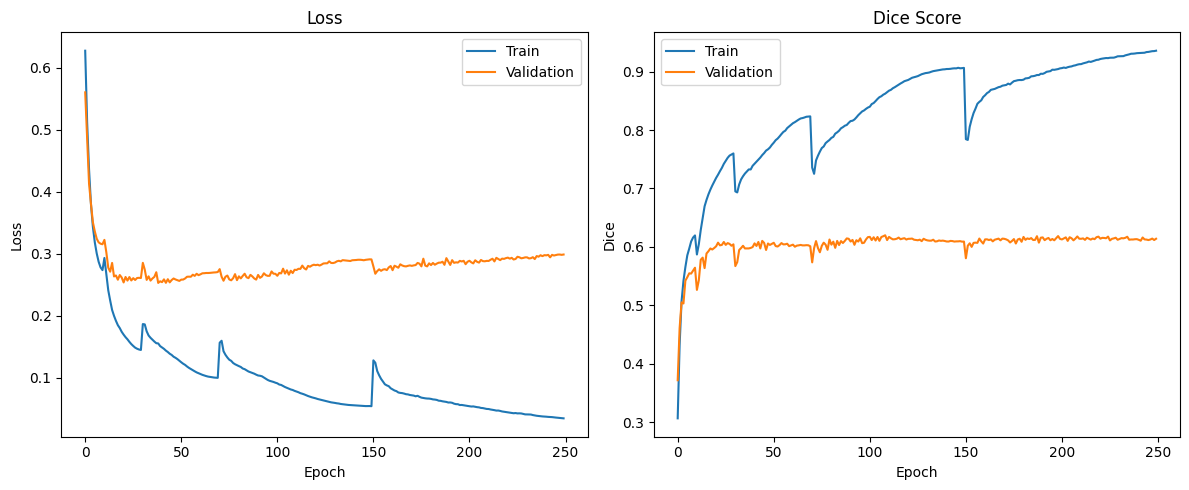

In [45]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")

plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Class Mask to RGB
# ============================================================

def classmask_to_rgb(mask):

    rgb = np.zeros(
        (mask.shape[0], mask.shape[1], 3),
        dtype=np.uint8
    )

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb

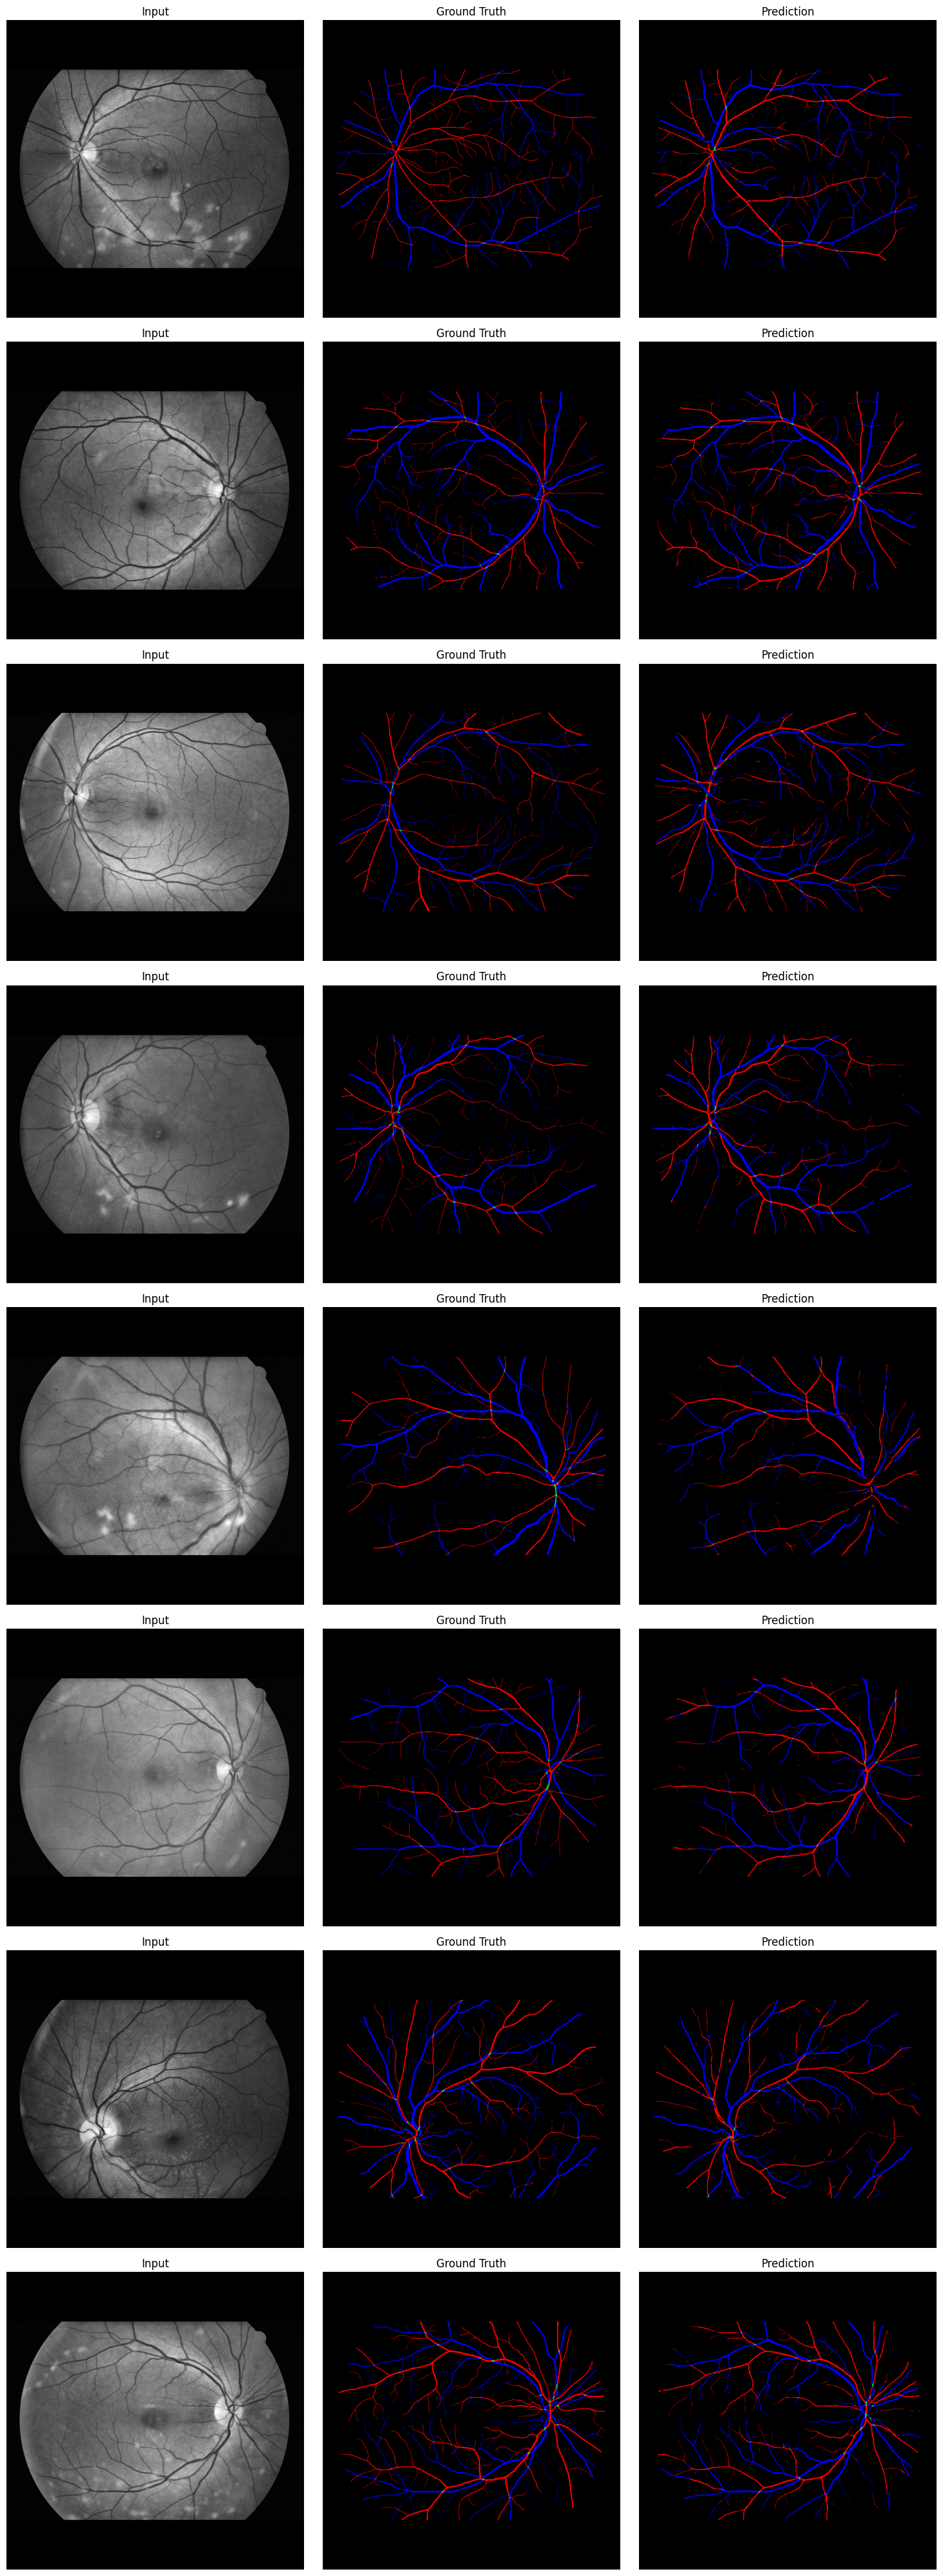

In [47]:
# ============================================================
# Visualization
# ============================================================

num_examples = 8

indices = np.random.choice(
    len(test_dataset),
    num_examples,
    replace=False
)

plt.figure(figsize=(15, 5 * num_examples))

for row, idx in enumerate(indices):

    image, gt = test_dataset[idx]

    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(DEVICE)
        )

    pred = torch.argmax(
        output,
        dim=1
    ).squeeze().cpu().numpy()

    gt = gt.numpy()

    pred_rgb = classmask_to_rgb(pred)

    gt_rgb = classmask_to_rgb(gt)

    image = image.squeeze().numpy()

    plt.subplot(num_examples, 3, row * 3 + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(num_examples, 3, row * 3 + 2)
    plt.imshow(gt_rgb)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_examples, 3, row * 3 + 3)
    plt.imshow(pred_rgb)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()

plt.show()